In [1]:
!pip install torch torchvision

In [8]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from src.utils import load_cifar10_longtail
import numpy as np
from tqdm import tqdm # Thư viện hiện thanh tiến trình

# 1. Thiết lập thiết bị
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device}")

# 2. Tải Model DINOv2
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
model.eval()

# 3. Transform chuẩn
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Lớp hỗ trợ để đưa dữ liệu vào DataLoader ---
class CifarLongtailDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img

# 4. Hàm trích xuất đặc trưng tối ưu (Xử lý theo Batch)
def extract_features_fast(X_images, batch_size=32):
    dataset = CifarLongtailDataset(X_images, transform=transform)
    # DataLoader giúp gộp các ảnh thành Batch để xử lý song song
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    feats = []
    # tqdm sẽ tạo ra thanh tiến trình cực đẹp
    with torch.no_grad():
        for batch in tqdm(loader, desc="Đang trích xuất đặc trưng"):
            batch = batch.to(device)
            feat = model(batch)
            feats.append(feat.cpu().numpy())
            
    return np.vstack(feats)

# --- THỰC THI ---

X_longtail, Y_longtail = load_cifar10_longtail('../data/cifar-10-batches-py', imbalance_ratio=0.1)

# Trích xuất với Batch size 64 (Nếu máy có GPU mạnh bạn có thể tăng lên 128)
X_features = extract_features_fast(X_longtail, batch_size=64)

print(f"Xong! Kích thước mảng đặc trưng: {X_features.shape}")

# --- QUAN TRỌNG: Lưu lại để không phải chạy lại lần nữa ---
# Bạn hãy tạo folder 'processed_data' nếu chưa có
os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/X_features_cifar_0.1.npy', X_features)
np.save('../data/processed/Y_longtail_cifar_0.1.npy', Y_longtail)
print("Đã lưu đặc trưng vào thư mục data/processed/")

Đang sử dụng thiết bị: cpu


Using cache found in C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main


Lớp 0: giữ lại 5000 ảnh
Lớp 1: giữ lại 3871 ảnh
Lớp 2: giữ lại 2997 ảnh
Lớp 3: giữ lại 2320 ảnh
Lớp 4: giữ lại 1796 ảnh
Lớp 5: giữ lại 1391 ảnh
Lớp 6: giữ lại 1077 ảnh
Lớp 7: giữ lại 834 ảnh
Lớp 8: giữ lại 645 ảnh
Lớp 9: giữ lại 500 ảnh


Đang trích xuất đặc trưng: 100%|██████████| 320/320 [18:55<00:00,  3.55s/it]


Xong! Kích thước mảng đặc trưng: (20431, 384)
Đã lưu đặc trưng vào thư mục data/processed/


In [1]:
import numpy as np
import sys
import os
from sklearn.cluster import KMeans

# 1. Thêm đường dẫn src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.model import hierarchical_kmeans_resampling

# 2. Load dữ liệu đặc trưng đã lưu (Đảm bảo đúng đường dẫn trong ảnh của bạn)
X_features = np.load('../data/processed/X_features_cifar_0.1.npy').astype(np.float32)
Y_longtail = np.load('../data/processed/Y_longtail_cifar_0.1.npy')

print(f"Đã load xong X_features: {X_features.shape}")
print(f"Đã load xong Y_longtail: {Y_longtail.shape}")

Đã load xong X_features: (20431, 384)
Đã load xong Y_longtail: (20431,)


In [ ]:
from sklearn.preprocessing import normalize

# 1. QUAN TRỌNG: Chuẩn hóa L2 cho features
X_feat_norm = normalize(X_features, axis=1)

# 2. Chạy lại HK-means với số cụm lớn hơn để tăng độ mịn concept
# Tầng cuối chọn 500 cụm thay vì 100
k_list_fine = [2000, 500, 100] 
centroids_cifar = hierarchical_kmeans_resampling(
    X_feat_norm, k_list_fine, T=3, m=10, r_t_list=[5, 2, 1], num_init=5
)

# 3. Gán nhãn lại
km_fine = KMeans(n_clusters=500, init=centroids_cifar, n_init=1).fit(X_feat_norm)
labels_fine = km_fine.labels_

# 4. Lấy mẫu cực thưa: Mỗi cụm chỉ lấy 2 ảnh gần tâm nhất (Tổng 1000 ảnh)
curated_idx = []
for i in range(500):
    idx_cluster = np.where(labels_fine == i)[0]
    if len(idx_cluster) == 0: continue
    
    d = np.linalg.norm(X_feat_norm[idx_cluster] - centroids_cifar[i], axis=1)
    # Lấy 2 ảnh thay vì 10
    top_idx = idx_cluster[np.argsort(d)[:2]]
    curated_idx.extend(top_idx)

Y_curated_new = Y_longtail[curated_idx]

# --- VẼ LẠI BIỂU ĐỒ VÀ TÍNH ENTROPY ---
# (Dùng lại code vẽ biểu đồ ở bước trước của tôi)

--- Level 1/3 (k=1000, r_t=5) ---
--- Level 2/3 (k=700, r_t=2) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 3/3 (k=500, r_t=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

In [6]:
# --- 1. Lấy mẫu ngẫu nhiên (Random Sampling - Baseline) ---
# Chọn đại 1000 ảnh từ toàn bộ dữ liệu gốc
random_indices = np.random.choice(len(X_features), 1000, replace=False)
Y_random_subset = Y_longtail[random_indices]

# --- 2. Lấy mẫu theo HK-means (Our Balanced Sampling) ---
# Từ mỗi cụm trong 100 cụm, lấy 10 ảnh gần tâm nhất (tổng 1000 ảnh)
curated_indices = []
for i in range(100):
    idx_in_cluster = np.where(cluster_labels == i)[0]
    if len(idx_in_cluster) == 0: continue
    
    # Tính khoảng cách tới tâm cụm i
    dists = np.linalg.norm(X_features[idx_in_cluster] - centroids_final[i], axis=1)
    # Lấy 10 ảnh gần nhất
    top_k_idx = idx_in_cluster[np.argsort(dists)[:10]]
    curated_indices.extend(top_k_idx)

Y_curated_subset = Y_longtail[curated_indices]

In [7]:
import matplotlib.pyplot as plt

# --- 1. Lấy mẫu ngẫu nhiên (Random Sampling - Baseline) ---
# Chọn đại 1000 chỉ số từ toàn bộ 20.431 ảnh
random_indices = np.random.choice(len(X_features), 1000, replace=False)
Y_random_subset = Y_longtail[random_indices]

# --- 2. Lấy mẫu theo HK-means (Ours - Balanced Sampling) ---
# Ý tưởng: Từ mỗi cụm trong 100 cụm (concept), lấy 10 ảnh gần tâm nhất
curated_indices = []
for i in range(100):
    # Tìm các ảnh thuộc cụm i
    idx_in_cluster = np.where(cluster_labels == i)[0]
    if len(idx_in_cluster) == 0: continue
    
    # Tính khoảng cách từ các ảnh trong cụm tới tâm cụm i tương ứng
    dists = np.linalg.norm(X_features[idx_in_cluster] - centroids_final[i], axis=1)
    
    # Lấy 10 ảnh có khoảng cách nhỏ nhất (đại diện tốt nhất cho concept đó)
    top_k_local_idx = np.argsort(dists)[:10]
    curated_indices.extend(idx_in_cluster[top_k_local_idx])

Y_curated_subset = Y_longtail[curated_indices]

print(f"Số lượng mẫu tập Random: {len(Y_random_subset)}")
print(f"Số lượng mẫu tập HK-means: {len(Y_curated_subset)}")

Số lượng mẫu tập Random: 1000
Số lượng mẫu tập HK-means: 910


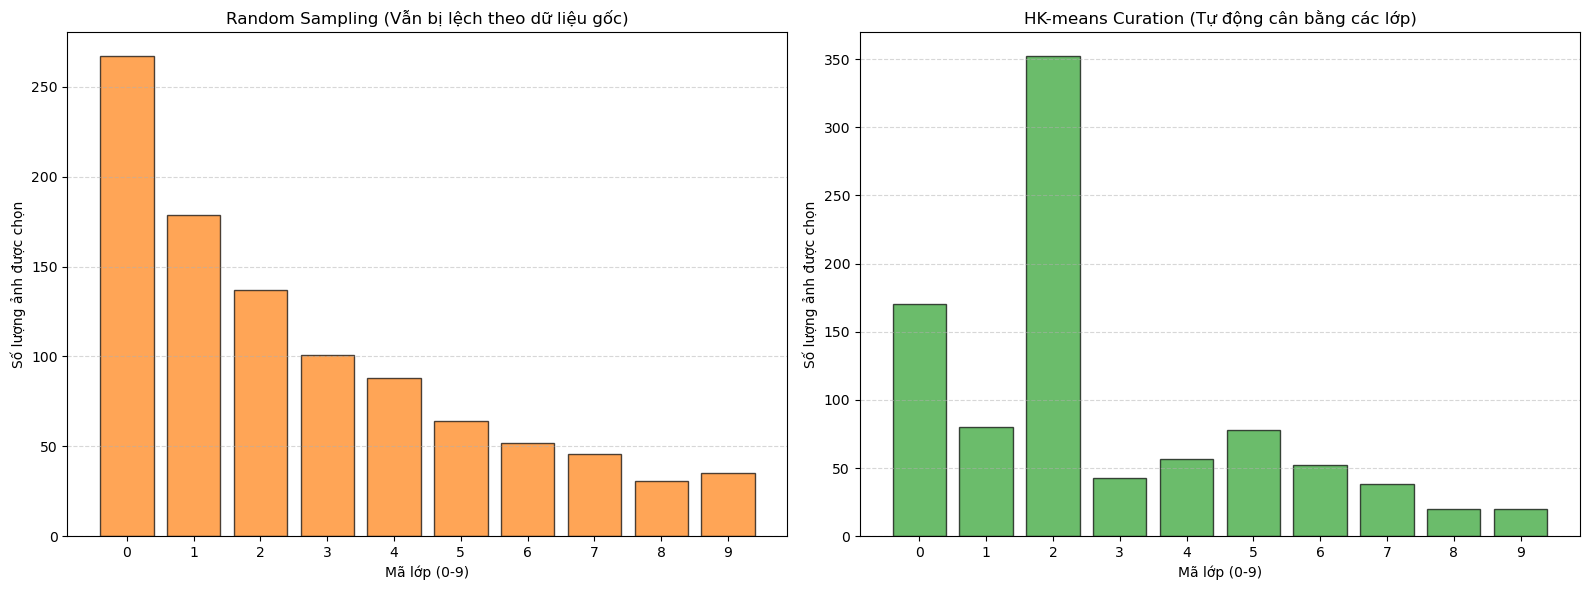

In [8]:
def plot_distribution(y_data, title, color):
    classes, counts = np.unique(y_data, return_counts=True)
    # Đảm bảo đủ 10 lớp dù có lớp không được chọn
    full_counts = np.zeros(10)
    for cls, count in zip(classes, counts):
        full_counts[cls] = count
        
    plt.bar(range(10), full_counts, color=color, alpha=0.7, edgecolor='black')
    plt.xlabel('Mã lớp (0-9)')
    plt.ylabel('Số lượng ảnh được chọn')
    plt.title(title)
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.figure(figsize=(16, 6))

# Biểu đồ bên trái: Random
plt.subplot(1, 2, 1)
plot_distribution(Y_random_subset, "Random Sampling (Vẫn bị lệch theo dữ liệu gốc)", "tab:orange")

# Biểu đồ bên phải: HK-means (Ours)
plt.subplot(1, 2, 2)
plot_distribution(Y_curated_subset, "HK-means Curation (Tự động cân bằng các lớp)", "tab:green")

plt.tight_layout()
plt.show()